<a href="https://colab.research.google.com/github/pandita56666/SPIS-ML-Seismic-Performance-Intelligent-System/blob/main/REGRESI%C3%93N_LINEAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Upload drive files
from google.colab import files
from google.colab import drive

drive.mount ('/content/drive')

Mounted at /content/drive


a = 9.9483, b = 1.0222
RMSE = 892.07 (7.62%)
MAE = 673.45 (5.75%)
R² = 0.983


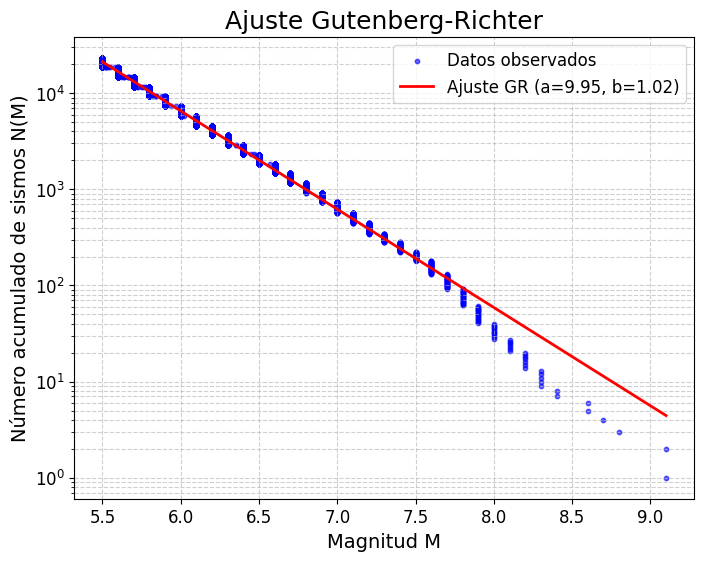

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === 1. Cargar tus datos ===
rutaA = '/content/database.csv'
df = pd.read_csv(rutaA)

# Asegurarse de que la columna se llame 'Magnitude'
df = df.dropna(subset=['Magnitude'])

# === 2. Ordenar magnitudes de mayor a menor ===
magnitudes = np.sort(df["Magnitude"].values)[::-1]

# Número acumulado N(M)
N_obs = np.arange(1, len(magnitudes) + 1)

# === 3. Ajuste Gutenberg-Richter ===
slope, intercept, r, p, se = linregress(magnitudes, np.log10(N_obs))
a = intercept
b = -slope   # pendiente negativa

# N predicho
N_pred = 10**(a - b * magnitudes)

# === 4. Métricas ===
rmse = np.sqrt(mean_squared_error(N_obs, N_pred))
mae = mean_absolute_error(N_obs, N_pred)
r2 = r2_score(N_obs, N_pred)

# Calcular los porcentajes respecto al promedio de los valores observados
mean_obs = np.mean(N_obs)
rmse_pct = (rmse / mean_obs) * 100
mae_pct = (mae / mean_obs) * 100

# === 5. Resultados ===
print(f"a = {a:.4f}, b = {b:.4f}")
print(f"RMSE = {rmse:.2f} ({rmse_pct:.2f}%)")
print(f"MAE = {mae:.2f} ({mae_pct:.2f}%)")
print(f"R² = {r2:.3f}")

# === 6. Gráfica ===
plt.figure(figsize=(8,6))

plt.scatter(
    magnitudes,
    N_obs,
    label="Datos observados",
    color="blue",
    s=10,
    alpha=0.6
)

plt.plot(
    magnitudes,
    N_pred,
    label=f"Ajuste GR (a={a:.2f}, b={b:.2f})",
    color="red",
    linewidth=2
)

plt.yscale("log")

# Tamaño de texto
plt.xlabel("Magnitud M", fontsize=14)
plt.ylabel("Número acumulado de sismos N(M)", fontsize=14)
plt.title("Ajuste Gutenberg-Richter", fontsize=18)

# Tamaño de números en ejes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Tamaño de la leyenda
plt.legend(fontsize=12)

plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.show()


In [ ]:
# Digamos que para M=6 el modelo da N=0.05 por año (un sismo cada 20 años en promedio)
M=8.5
N = 10**(a - b*M)
lambd = N /44.19 # tasa anual
T = 1       # horizonte de predicción en años

prob = 1 - np.exp(-lambd * T)
print(f"Probabilidad de ≥1 sismo M>=6 en {T} años: {prob*100:.1f}%")


Probabilidad de ≥1 sismo M>=6 en 1 años: 33.7%


**RL CON ESCALA LOGARITMICA**

a = 9.9483, b = 1.0222
RMSE (log10) = 0.0336 (0.85%)
MAE (log10) = 0.0262 (0.67%)
R² = 0.994


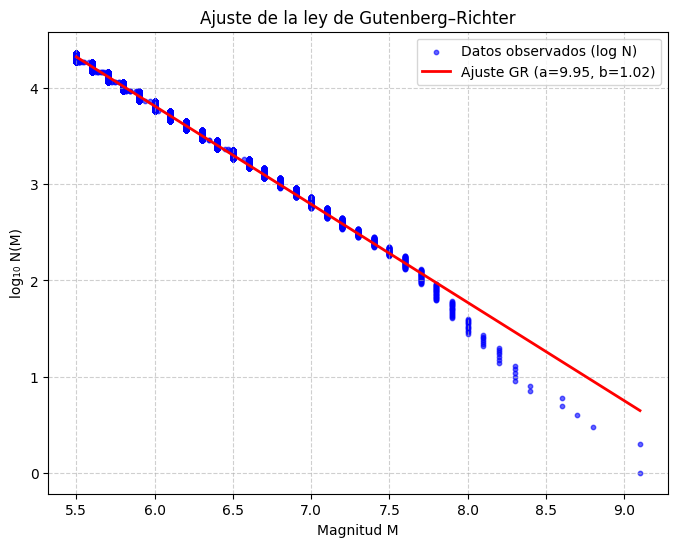

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === 1. Cargar datos ===
rutaA = '/content/database.csv'
df = pd.read_csv(rutaA)
df = df.dropna(subset=['Magnitude'])

# === 2. Ordenar magnitudes ===
magnitudes = np.sort(df["Magnitude"].values)[::-1]
N_obs = np.arange(1, len(magnitudes) + 1)

# === 3. Convertir a escala logarítmica ===
log_N_obs = np.log10(N_obs)

# === 4. Ajuste lineal de la Ley de Gutenberg–Richter ===
slope, intercept, r, p, se = linregress(magnitudes, log_N_obs)
a = intercept
b = -slope

# Predicciones en escala logarítmica
log_N_pred = intercept + slope * magnitudes

# === 5. Métricas en escala logarítmica ===
rmse = np.sqrt(mean_squared_error(log_N_obs, log_N_pred))
mae = mean_absolute_error(log_N_obs, log_N_pred)
r2 = r2_score(log_N_obs, log_N_pred)

# Porcentajes relativos (respecto al promedio logarítmico)
mean_obs = np.mean(log_N_obs)
rmse_pct = (rmse / mean_obs) * 100
mae_pct = (mae / mean_obs) * 100

# === 6. Resultados ===
print(f"a = {a:.4f}, b = {b:.4f}")
print(f"RMSE (log10) = {rmse:.4f} ({rmse_pct:.2f}%)")
print(f"MAE (log10) = {mae:.4f} ({mae_pct:.2f}%)")
print(f"R² = {r2:.3f}")

# === 7. Gráfica ===
plt.figure(figsize=(8,6))
plt.scatter(magnitudes, log_N_obs, label="Datos observados (log N)", color="blue", s=10, alpha=0.6)
plt.plot(magnitudes, log_N_pred, label=f"Ajuste GR (a={a:.2f}, b={b:.2f})", color="red", linewidth=2)

plt.xlabel("Magnitud M")
plt.ylabel("log₁₀ N(M)")
plt.title("Ajuste de la ley de Gutenberg–Richter")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()
